In [3]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from flowpde.datasets import DarcyConfig, DarcyGenerator
from flowpde.models.unet import UNet
from flowpde.datasets.normalization import FieldNormalizer
from flowpde.flows import NeuralODEFlow
from flowpde.objectives import FlowMatchingObjective
from flowpde.trainers.evaluation import FlowEvaluator
from flowpde.trainers import Trainer

In [4]:
cfg = DarcyConfig()
generator = DarcyGenerator(cfg)
train_data = generator.generate(num_samples=1000, seed=0, problem='forward')
val_data = generator.generate(num_samples=50, seed=1, problem='forward')

Generated Darcy 2D dataset: 1000 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=500
Generated Darcy 2D dataset: 50 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=500


In [5]:
def visualize_darcy_dataset(dataset, n=6, title=None):
    """
    Visualize Darcy forward dataset:
        kappa  : permeability field
        source : forcing/source field f
        solution : PDE solution u
    """

    data = dataset.get_raw_data()

    kappa = data["kappa"]       # (N, 1, H, W)
    source = data["source"]     # (N, 1, H, W)
    solution = data["solution"] # (N, 1, H, W)

    n = min(n, len(dataset))

    fig, axes = plt.subplots(
        3, n,
        figsize=(2.6 * n, 7.8),
        constrained_layout=True,
        squeeze=False,
    )

    for j in range(n):
        k = kappa[j, 0].cpu().numpy()
        f = source[j, 0].cpu().numpy()
        u = solution[j, 0].cpu().numpy()

        vmax_f = abs(f).max()
        vmax_u = abs(u).max()

        rows = [
            (k, r"permeability $\kappa$", "viridis", None, None),
            (f, r"source $f$", "RdBu_r", -vmax_f, vmax_f),
            (u, r"solution $u$", "viridis", -vmax_u, vmax_u),
        ]

        for row, (field, name, cmap, vmin, vmax) in enumerate(rows):
            ax = axes[row, j]

            im = ax.imshow(
                field,
                cmap=cmap,
                origin="lower",
                vmin=vmin,
                vmax=vmax,
            )

            ax.set_xticks([])
            ax.set_yticks([])

            if j == 0:
                ax.set_ylabel(name, fontsize=11)

            if row == 0:
                ax.set_title(f"sample {j}", fontsize=9)

            fig.colorbar(im, ax=ax, fraction=0.046, shrink=0.9)

    if title is None:
        title = r"Darcy flow: $-\nabla \cdot (\kappa \nabla u) = f$"

    fig.suptitle(title, fontsize=13)
    plt.show()

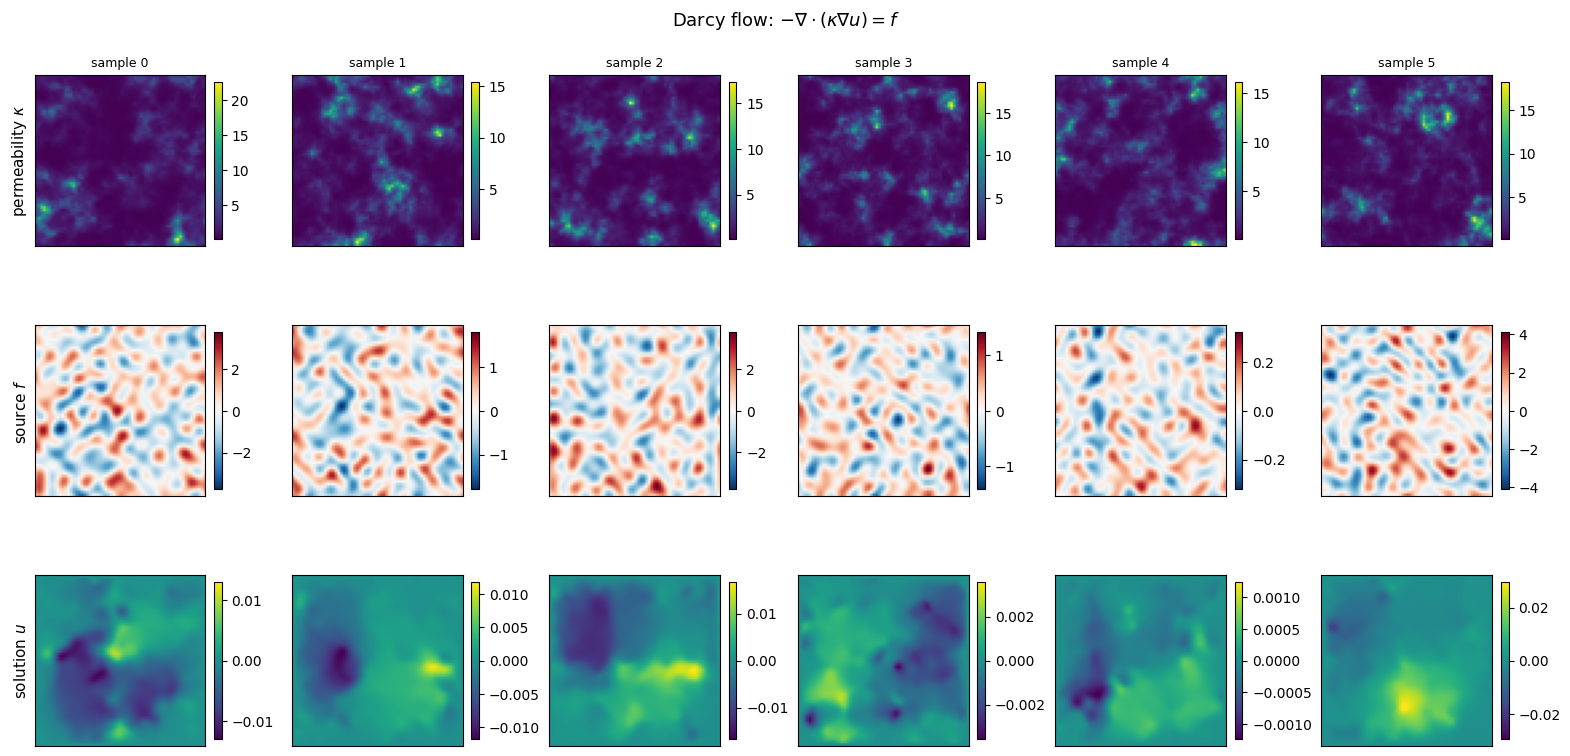

In [6]:
visualize_darcy_dataset(train_data, n=6)

In [7]:
normalizer = FieldNormalizer.from_dataset(train_data)
train_data.set_normalizer(normalizer)
val_data.set_normalizer(normalizer)

In [8]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)
sample = train_data[0]
cond_ch = sample['input'].shape[0]      # +1 if obs masking is on
targ_ch = sample['target'].shape[0]
cond_ch, targ_ch

(2, 1)

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model = UNet(spatial_dim = 2,
            spatial_size = 64,
            base_channels = 16,
            solution_channels = targ_ch,
            condition_channels = cond_ch,
            use_attention = False).to(device)

Using device: cuda


In [17]:
flow = NeuralODEFlow(
    model,
    target_key="target",
    condition_key="input",
).to(device)
objective = FlowMatchingObjective(flow, path='linear', time_sampler='uniform')
optimizer = torch.optim.Adam(objective.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

In [18]:
evaluator = FlowEvaluator(objective, 
                          val_loader,
                          target_key='target',
                          condition_key='input',
                          n_steps = 50,
                          solver='euler',
                          normalizer=normalizer,
                          target_fields=val_data.target_fields,
                          metrics=['rel_l2'],
                          max_batches=4,)

In [19]:
trainer = Trainer(objective,
                  optimizer,
                  scheduler,
                  device)

In [20]:
trainer.train(train_loader,
             epochs = 1000,
             print_stats_interval = 10,
             save_dir='../runs/darcy2d_fm',
             save_interval=25)

Epoch: 0001/1000 | Train_Loss: 1.950438 | LR: 1.00e-03 | Time: 0.983439
Epoch: 0011/1000 | Train_Loss: 0.435051 | LR: 9.93e-04 | Time: 0.486839
Epoch: 0021/1000 | Train_Loss: 0.338827 | LR: 9.73e-04 | Time: 0.475376
Epoch: 0031/1000 | Train_Loss: 0.306888 | LR: 9.42e-04 | Time: 0.442589
Epoch: 0041/1000 | Train_Loss: 0.244479 | LR: 9.00e-04 | Time: 0.496969
Epoch: 0051/1000 | Train_Loss: 0.191182 | LR: 8.48e-04 | Time: 0.485498
Epoch: 0061/1000 | Train_Loss: 0.162067 | LR: 7.88e-04 | Time: 0.493617
Epoch: 0071/1000 | Train_Loss: 0.131223 | LR: 7.20e-04 | Time: 0.448659
Epoch: 0081/1000 | Train_Loss: 0.12443 | LR: 6.47e-04 | Time: 0.443585
Epoch: 0091/1000 | Train_Loss: 0.10383 | LR: 5.70e-04 | Time: 0.44779
Epoch: 0101/1000 | Train_Loss: 0.090939 | LR: 4.92e-04 | Time: 0.447604
Epoch: 0111/1000 | Train_Loss: 0.089643 | LR: 4.14e-04 | Time: 0.444918
Epoch: 0121/1000 | Train_Loss: 0.072363 | LR: 3.38e-04 | Time: 0.445254
Epoch: 0131/1000 | Train_Loss: 0.074027 | LR: 2.66e-04 | Time: 0.44

In [21]:
batch = next(iter(val_loader))

condition = batch["input"].to(device)   # normalized [kappa, source]
target = batch["target"].to(device)     # normalized true solution u

with torch.no_grad():
    x_init = torch.randn_like(target)

    pred = objective.sample(
        condition=condition,
        n_steps=100,
        solver="euler",
        x_init=x_init,
    )

    pred = pred.reshape_as(target)

In [22]:
pred_real = normalizer.denormalize_channels(
    val_data.target_fields,
    pred.cpu()
)

target_real = normalizer.denormalize_channels(
    val_data.target_fields,
    target.cpu()
)

condition_real = normalizer.denormalize_channels(
    val_data.input_fields,
    condition.cpu()
)

In [23]:
kappa_real = condition_real[:, 0:1]
source_real = condition_real[:, 1:2]

In [24]:
rel_l2 = (
    torch.linalg.vector_norm((pred_real - target_real).flatten(1), dim=1)
    / torch.linalg.vector_norm(target_real.flatten(1), dim=1).clamp_min(1e-8)
)

print("Mean relative L2:", rel_l2.mean().item())

Mean relative L2: 0.23381926119327545


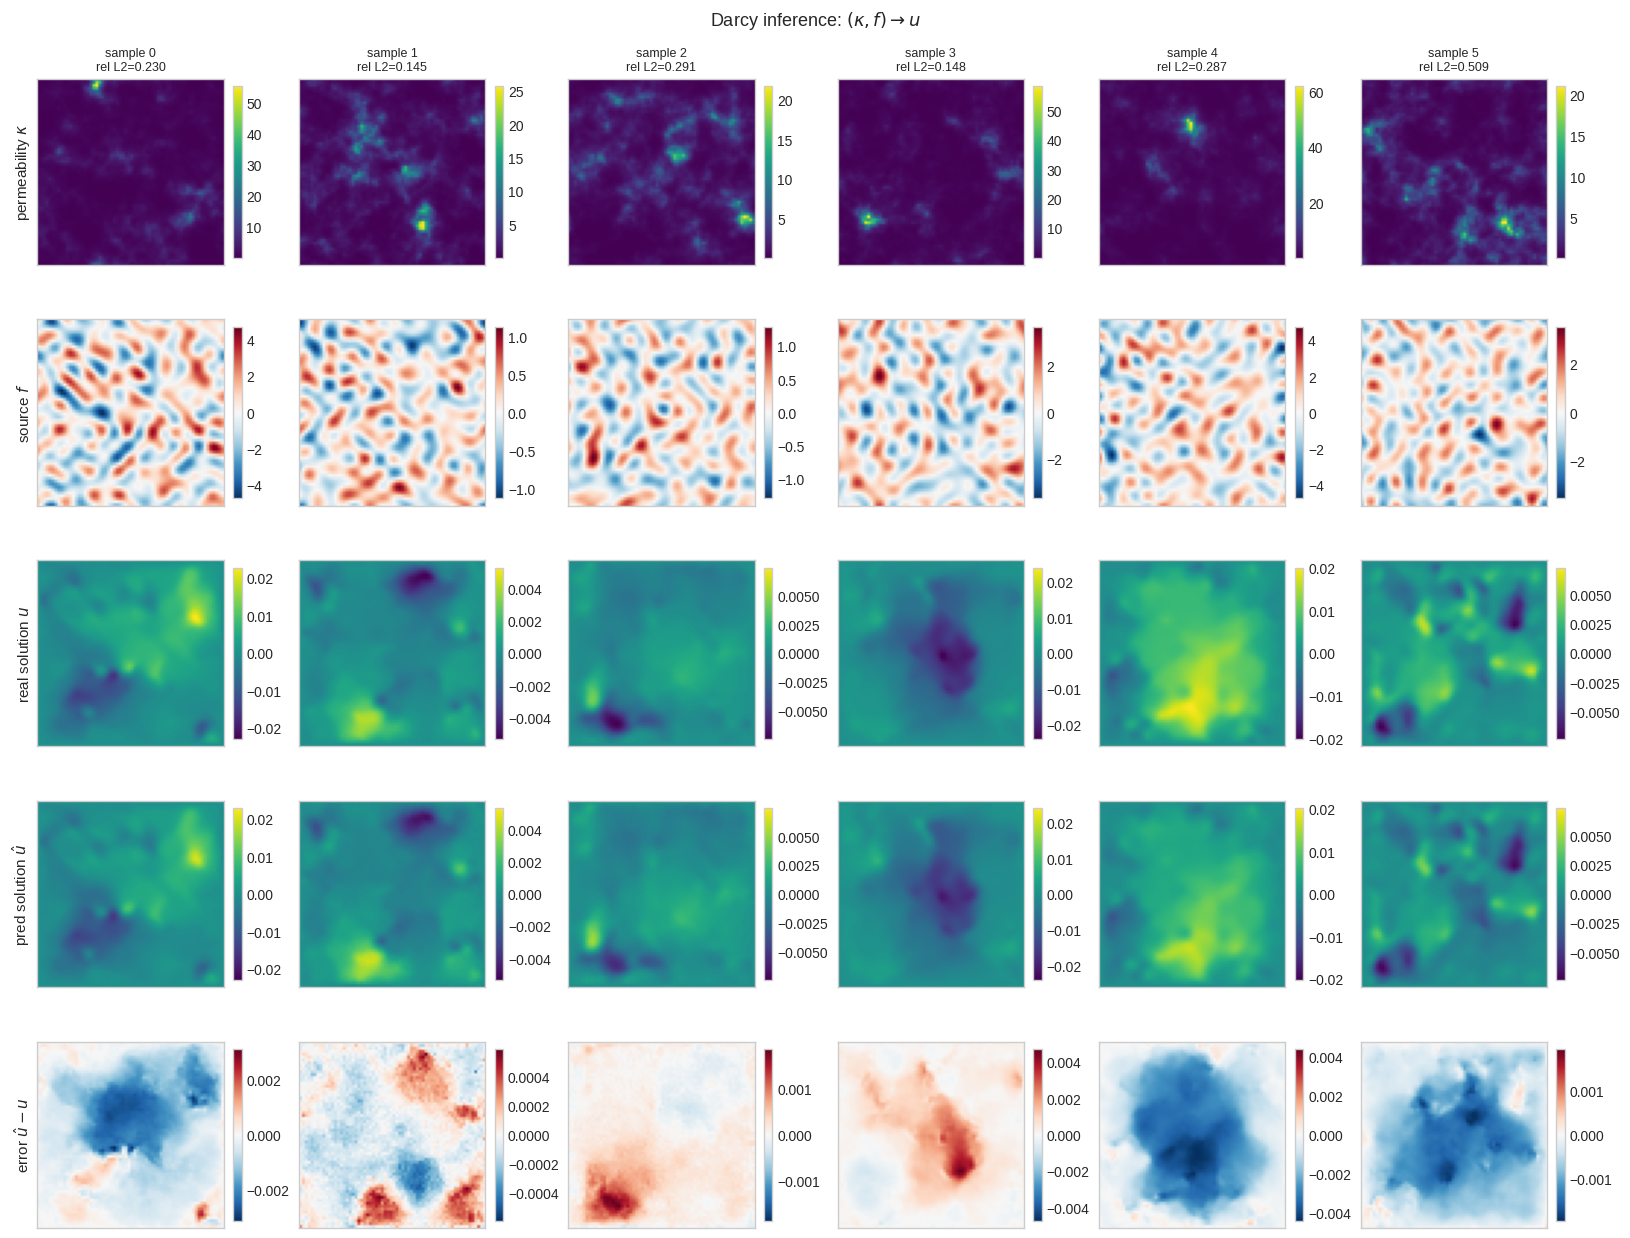

In [25]:
n = 6

fig, axes = plt.subplots(
    5, n,
    figsize=(2.7 * n, 12.5),
    constrained_layout=True,
    squeeze=False,
)

for j in range(n):
    kappa = kappa_real[j, 0].numpy()
    source = source_real[j, 0].numpy()
    u_true = target_real[j, 0].numpy()
    u_pred = pred_real[j, 0].numpy()
    err = u_pred - u_true

    vmax_source = abs(source).max()
    vmax_u = max(abs(u_true).max(), abs(u_pred).max())
    vmax_err = abs(err).max()

    rows = [
        (kappa, r"permeability $\kappa$", "viridis", None, None),
        (source, r"source $f$", "RdBu_r", -vmax_source, vmax_source),
        (u_true, r"real solution $u$", "viridis", -vmax_u, vmax_u),
        (u_pred, r"pred solution $\hat{u}$", "viridis", -vmax_u, vmax_u),
        (err, r"error $\hat{u} - u$", "RdBu_r", -vmax_err, vmax_err),
    ]

    for row, (field, label, cmap, vmin, vmax) in enumerate(rows):
        ax = axes[row, j]

        im = ax.imshow(
            field,
            cmap=cmap,
            origin="lower",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_xticks([])
        ax.set_yticks([])

        if j == 0:
            ax.set_ylabel(label, fontsize=11)

        if row == 0:
            ax.set_title(f"sample {j}\nrel L2={rel_l2[j]:.3f}", fontsize=9)

        fig.colorbar(im, ax=ax, fraction=0.046, shrink=0.9)

fig.suptitle(
    r"Darcy inference: $(\kappa, f) \rightarrow u$",
    fontsize=13,
)
plt.show()